
Affinity rules, scaled from 3000 RPM
  RPM  Q [l/min]  H meas [m]  H calc [m]  dev [%]
 2000        1.7        5.00        4.86      2.8
 2000       28.0        3.90        3.73      4.7
 2000       32.6        3.70        3.52      5.0
 1000        6.9        1.20        1.09     10.5
 1000        8.1        1.20        1.06     13.2
 1000       10.2        1.10        1.01      8.4


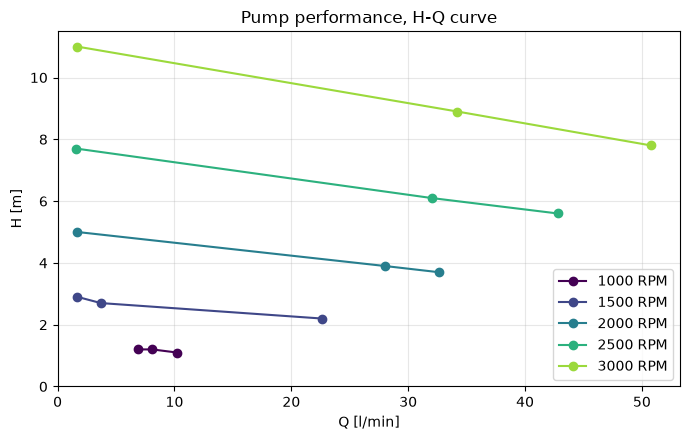

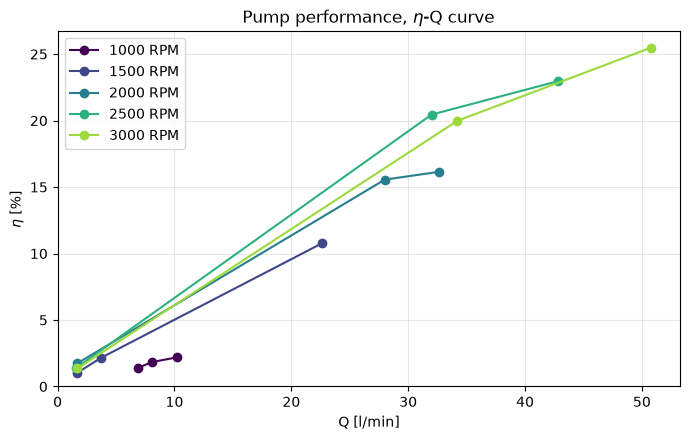

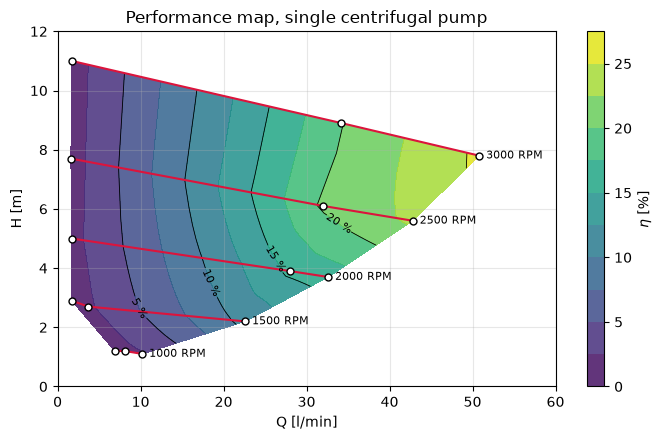

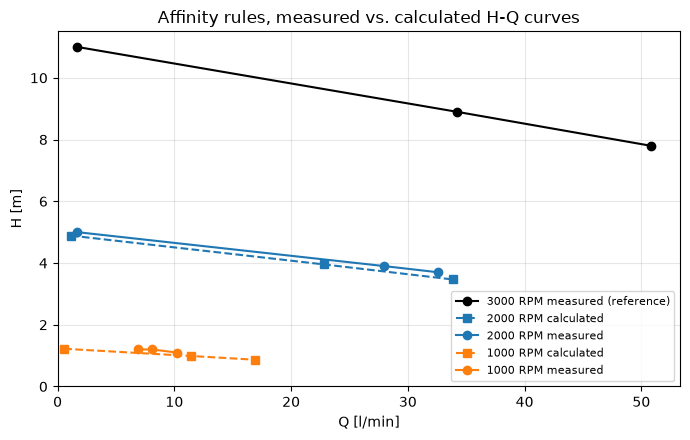

In [6]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Raw data from the panel: Q [l/min] (SC-1), Ht [m], eta [%]
data = {
    1000: {"Q": [10.2, 8.1, 6.9], "H": [1.1, 1.2, 1.2], "eta": [2.19, 1.84, 1.41]},
    1500: {"Q": [22.6, 3.7, 1.7], "H": [2.2, 2.7, 2.9], "eta": [10.76, 2.15, 1.04]},
    2000: {"Q": [32.6, 28.0, 1.7], "H": [3.7, 3.9, 5.0], "eta": [16.14, 15.56, 1.75]},
    2500: {"Q": [42.8, 32.0, 1.6], "H": [5.6, 6.1, 7.7], "eta": [22.96, 20.45, 1.40]},
    3000: {"Q": [50.8, 34.2, 1.7], "H": [7.8, 8.9, 11.0], "eta": [25.49, 19.98, 1.36]},
}

colors = plt.cm.viridis(np.linspace(0, 0.85, len(data)))

# Save figures next to the script, or in the current folder in Jupyter
try:
    output_dir = Path(__file__).parent / "figures"
except NameError:
    output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)


def sorted_curve(d, key):
    """Return Q and the chosen quantity sorted by increasing flow."""
    order = np.argsort(d["Q"])
    return np.array(d["Q"])[order], np.array(d[key])[order]


def plot_curve(key, ylabel, title, fname):
    """Task 1: plot H-Q or eta-Q curves for all speeds."""
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for c, (rpm, d) in zip(colors, data.items()):
        Q, y = sorted_curve(d, key)
        ax.plot(Q, y, "o-", color=c, lw=1.5, label=f"{rpm} RPM")
    ax.set_xlabel("Q [l/min]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"{fname}.pdf")


def plot_performance_map(fname):
    s = np.linspace(0, 1, 30)
    Q_grid, H_grid, eta_grid = [], [], []
    for rpm in sorted(data):
        Q, H = sorted_curve(data[rpm], "H")
        _, eta = sorted_curve(data[rpm], "eta")
        t = (Q - Q[0]) / (Q[-1] - Q[0])
        Q_grid.append(np.interp(s, t, Q))
        H_grid.append(np.interp(s, t, H))
        eta_grid.append(np.interp(s, t, eta))
    Q_grid, H_grid, eta_grid = map(np.array, (Q_grid, H_grid, eta_grid))

    fig, ax = plt.subplots(figsize=(7, 4.5))

    # Filled iso-efficiency areas + labelled contour lines
    levels = np.arange(0, 28, 2.5)
    cf = ax.contourf(Q_grid, H_grid, eta_grid, levels=levels, cmap="viridis", alpha=0.85)
    cl = ax.contour(Q_grid, H_grid, eta_grid, levels=levels[::2], colors="k", linewidths=0.6)
    ax.clabel(cl, fmt="%.0f %%", fontsize=8)
    fig.colorbar(cf, ax=ax, label=r"$\eta$ [%]")

    # Measured H-Q curve for each speed on top
    for rpm, d in data.items():
        q, h = sorted_curve(d, "H")
        ax.plot(q, h, "o-", color="crimson", mfc="w", mec="k", lw=1.5, ms=5)
        ax.annotate(f"{rpm} RPM", (q[-1], h[-1]), xytext=(5, 0),
                    textcoords="offset points", fontsize=8, va="center")

    ax.set_xlabel("Q [l/min]")
    ax.set_ylabel("H [m]")
    ax.set_title("Performance map, single centrifugal pump")
    ax.set_xlim(0, 60)
    ax.set_ylim(0, 12)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(output_dir / f"{fname}.pdf")


def affinity(n_ref, n_targets, fname):
    """Task 2: scale the n_ref curve with the affinity rules and compare
    with the measured curves at the target speeds."""
    Q_ref, H_ref = sorted_curve(data[n_ref], "H")

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(Q_ref, H_ref, "o-", color="k", lw=1.5,
            label=f"{n_ref} RPM measured (reference)")

    print(f"\nAffinity rules, scaled from {n_ref} RPM")
    print(f"{'RPM':>5} {'Q [l/min]':>10} {'H meas [m]':>11} "
          f"{'H calc [m]':>11} {'dev [%]':>8}")

    for c, n in zip(["tab:blue", "tab:orange"], n_targets):
        r = n / n_ref
        Q_calc = Q_ref * r          # Q ~ n
        H_calc = H_ref * r**2       # H ~ n^2

        Q_meas, H_meas = sorted_curve(data[n], "H")

        ax.plot(Q_calc, H_calc, "s--", color=c, lw=1.5, label=f"{n} RPM calculated")
        ax.plot(Q_meas, H_meas, "o-", color=c, lw=1.5, label=f"{n} RPM measured")

        # Compare at the measured flows: interpolate the calculated curve
        H_interp = np.interp(Q_meas, Q_calc, H_calc)
        dev = (H_meas - H_interp) / H_interp * 100
        for q, hm, hc, d in zip(Q_meas, H_meas, H_interp, dev):
            print(f"{n:>5} {q:>10.1f} {hm:>11.2f} {hc:>11.2f} {d:>8.1f}")

    ax.set_xlabel("Q [l/min]")
    ax.set_ylabel("H [m]")
    ax.set_title("Affinity rules, measured vs. calculated H-Q curves")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(output_dir / f"{fname}.pdf")


if __name__ == "__main__":
    plot_curve("H", "H [m]", "Pump performance, H-Q curve", "HQ_curve")
    plot_curve("eta", r"$\eta$ [%]", r"Pump performance, $\eta$-Q curve", "etaQ_curve")
    plot_performance_map("performance_map")
    affinity(3000, [2000, 1000], "affinity_HQ")
    plt.show()